<a href="https://colab.research.google.com/github/aljubic1/bioinformatika_projekt_alj/blob/main/notebooks/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Feature Engineering

## Cilj

Cilj ovog notebooka je pretvoriti peptidne sekvence iz pripremljenog skupa podataka u numeričke značajke koje modeli strojnog učenja mogu koristiti. Iz svake sekvence izračunat će se duljina, neto naboj, prosječna hidrofobnost i aminokiselinski sastav (AAC).

In [3]:
# Uvoz biblioteke pandas za rad s tabličnim podacima.
import pandas as pd

# Uvoz sys modula za dodavanje putanje do src direktorija.
import sys

# Dodavanje src direktorija u Python putanju.
sys.path.append("/content")

# Uvoz funkcije za izračun značajki.
from features import extract_features

In [4]:
# Putanja do konačnog pripremljenog skupa podataka.
dataset_path = "dataset.csv"

# Učitavanje skupa podataka.
dataset = pd.read_csv(dataset_path)

# Prikaz prvih pet redaka.
dataset.head()

,ID,SEQUENCE,label
0,1390,CFQWQRNARKVR,1
1,Seq8055_sampling_method=Wang-et-al_AMP=0_rep2,TEETKVIDSRLVSDGYQ,0
2,1661,WLNALLHHGLNCAKGVL,1
3,1552,RLWRIVVIRVAR,1
4,1585,ILGTILGLLKSL,1


## Pregled skupa podataka

Prije izračuna bioinformatičkih značajki provjerava se broj zapisa, raspodjela klasa i osnovne informacije o skupu podataka kako bi se potvrdilo da su podaci ispravno učitani.

In [5]:
# Dimenzije skupa podataka.
dataset.shape

(3344, 3)

In [6]:
# Broj uzoraka po klasama.
dataset["label"].value_counts()

,count
label,
1,1672
0,1672


In [7]:
# Provjera nedostajućih vrijednosti.
dataset.isnull().sum()

,0
ID,0
SEQUENCE,0
label,0


In [8]:
# Izračun bioinformatičkih značajki za cijeli skup podataka.
features_df = extract_features(dataset)

# Prikaz prvih pet redaka.
features_df.head()

,ID,SEQUENCE,length,net_charge,hydrophobicity,label,AAC_A,AAC_C,AAC_D,AAC_E,...,AAC_M,AAC_N,AAC_P,AAC_Q,AAC_R,AAC_S,AAC_T,AAC_V,AAC_W,AAC_Y
0,1390,CFQWQRNARKVR,12,4,-1.458333,1,0.083333,0.083333,0.000000,0.000000,...,0.0,0.083333,0.0,0.166667,0.250000,0.000000,0.000000,0.083333,0.083333,0.000000
1,Seq8055_sampling_method=Wang-et-al_AMP=0_rep2,TEETKVIDSRLVSDGYQ,17,-2,-0.817647,0,0.000000,0.000000,0.117647,0.117647,...,0.0,0.000000,0.0,0.058824,0.058824,0.117647,0.117647,0.117647,0.000000,0.058824
2,1661,WLNALLHHGLNCAKGVL,17,3,0.605882,1,0.117647,0.058824,0.000000,0.000000,...,0.0,0.117647,0.0,0.000000,0.000000,0.000000,0.000000,0.058824,0.058824,0.000000
3,1552,RLWRIVVIRVAR,12,4,0.691667,1,0.083333,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.333333,0.000000,0.000000,0.250000,0.083333,0.000000
4,1585,ILGTILGLLKSL,12,1,1.816667,1,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000


In [9]:
# Provjera dimenzija skupa značajki.
features_df.shape

(3344, 26)

In [10]:
# Spremanje skupa značajki za modeliranje.
features_df.to_csv(
    "features.csv",
    index=False
)

### Izračun bioinformatičkih značajki

U ovom koraku svaka peptidna sekvenca pretvorena je u numerički zapis. Izračunate su duljina sekvence, neto naboj, prosječna hidrofobnost te aminokiselinski sastav (AAC). Ove značajke omogućuju modelima strojnog učenja da analiziraju biološka svojstva peptida i razlikuju AMP od non-AMP sekvenci.

In [12]:
#Statistika glavnih značajki
features_df[["length", "net_charge", "hydrophobicity"]].describe()

,length,net_charge,hydrophobicity
count,3344.000000,3344.000000,3344.000000
mean,26.527512,2.570873,-0.225078
std,19.956650,3.764262,0.909018
min,1.000000,-17.000000,-3.900000
25%,13.000000,0.000000,-0.716786
50%,20.000000,2.000000,-0.225000
75%,31.000000,5.000000,0.305682
max,148.000000,30.000000,3.250000


In [13]:
#Usporedba po klasama
features_df.groupby("label")[["length", "net_charge", "hydrophobicity"]].mean()

,length,net_charge,hydrophobicity
label,,,
0,31.564593,0.653110,-0.255638
1,21.490431,4.488636,-0.194518


### Tumačenje rezultata
rezultati biološki smisleni , što je odličan znak da je sve ispravno izračunato.

Pogledaj što dobivamo:

Značajka	ne-AMP (0)	AMP (1)	Tumačenje
Duljina	31,56	21,49	AMP su u prosjeku kraći peptidi. ✅
Neto naboj	0,65	4,49	AMP imaju znatno veći pozitivan naboj. ✅
Hidrofobnost	-0,256	-0,195	AMP su u prosjeku nešto hidrofobniji. ✅

Ovo se slaže s onim što se očekuje za antimikrobne peptide:

kraći su ,
imam veći pozitivan naboj ,
često su umjereno hidrofobni , što im pomaže u interakciji s membranama mikroorganizama.

Iz tablice se može uočiti da antimikrobni peptidi (AMP) imaju manju prosječnu duljinu sekvence u odnosu na non-AMP peptide. Također, AMP sekvence imaju znatno veći prosječni neto naboj, što je očekivano jer pozitivno nabijeni peptidi lakše ostvaruju interakciju s negativno nabijenim membranama mikroorganizama.

Prosječna hidrofobnost također pokazuje razliku između klasa, iako je ona manja u odnosu na razliku u duljini i neto naboju. Dobiveni rezultati potvrđuju da odabrane bioinformatičke značajke mogu biti korisne za razlikovanje antimikrobnih i neantimikrobnih peptida.

### Tumačenje značajki

Usporedbom prosječnih vrijednosti po klasama može se vidjeti razlikuju li se AMP i non-AMP sekvence prema duljini, naboju i hidrofobnosti. Neto naboj i hidrofobnost posebno su važni jer antimikrobni peptidi često stupaju u interakciju s negativno nabijenim membranama mikroorganizama.

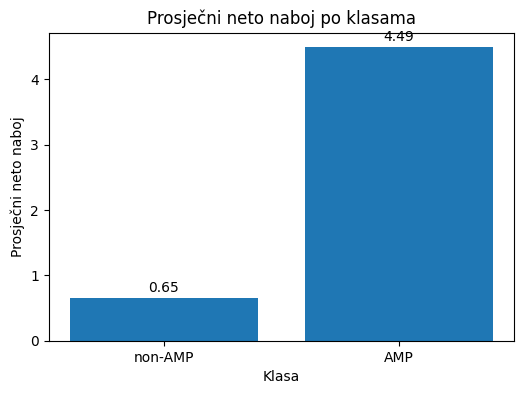

In [14]:
import matplotlib.pyplot as plt

# Prosječni neto naboj po klasama.
mean_charge = features_df.groupby("label")["net_charge"].mean()

plt.figure(figsize=(6,4))

plt.bar(
    ["non-AMP", "AMP"],
    mean_charge.values
)

plt.title("Prosječni neto naboj po klasama")
plt.xlabel("Klasa")
plt.ylabel("Prosječni neto naboj")

for i, value in enumerate(mean_charge.values):
    plt.text(i, value + 0.1, f"{value:.2f}", ha="center")

plt.show()

### Tumačenje rezultata

Graf prikazuje prosječni neto naboj peptida za obje klase u konačnom skupu podataka.

Može se uočiti da antimikrobni peptidi (AMP) imaju znatno veći prosječni neto naboj (**4,49**) u usporedbi s neantimikrobnim peptidima (non-AMP), čiji prosječni neto naboj iznosi **0,65**.

Pozitivan neto naboj jedno je od najvažnijih obilježja antimikrobnih peptida jer omogućuje njihovu interakciju s negativno nabijenim membranama bakterija i drugih mikroorganizama. Dobiveni rezultati potvrđuju da je neto naboj značajka koja može doprinijeti razlikovanju AMP i non-AMP peptida tijekom treniranja modela strojnog učenja.